In [11]:
# -------------------------------
# Dependencies
# -------------------------------
using Parameters, QuantEcon, NLopt
using Random, LinearAlgebra, Interpolations, Base.Threads, DataFrames, Statistics
using Plots, Statistics, ProgressMeter, ForwardDiff, Distributions, Profile
using DataFrames, Measures, StatsBase, LaTeXStrings, Printf, FastGaussQuadrature

In [32]:

# -------------------------------
# Utility: Nonlinear Grid Creator
# -------------------------------
function nonlinspace(start::Float64, stop::Float64, num::Int, curv::Float64)
    lin_vals = range(0, stop=1, length=num)
    curved_vals = lin_vals .^ curv
    return start .+ (stop - start) .* curved_vals
end

function create_focused_grid(a_min::Float64, a_focus::Float64, a_max::Float64, Na::Int, focus_share::Float64, curv::Float64)
    Na_focus = ceil(Int, Na * focus_share)
    Na_rest = Na - Na_focus
    grid_focus = nonlinspace(a_min, a_focus, Na_focus, curv)
    grid_rest = nonlinspace(a_focus, a_max, Na_rest + 1, curv)[2:end]
    return vcat(grid_focus, grid_rest)
end

# -------------------------------
# Dynamic Labor Model Definition
# -------------------------------
mutable struct ConSavLabor_stochastic
    T::Int                      # Time periods
    rho::Float64                # Risk aversion (CRRA)
    beta::Float64               # Discount factor
    phi::Float64                # Weight on labor disutility
    eta::Float64                # Frisch elasticity parameter
    alpha::Float64              # Productivity or returns to labor
    w::Float64                  # Base wage rate
    y::Float64                  # Non-labor income
    tau::Float64                # Labor income tax
    r::Float64                  # Interest rate
    a_max::Float64              # Max asset level
    a_min::Float64              # Min asset level
    Na::Int                     # Number of asset grid points
    k_max::Float64              # Max labor effort
    Nk::Int                     # Number of labor grid points
    simT::Int                   # Simulation time periods
    simN::Int                   # Number of simulated agents
    a_grid::Vector{Float64}     # Asset grid
    k_grid::Vector{Float64}     # Labor grid

    # Transitory shocks
    Nt::Int                     # Number of grid points for t
    t_grid::Vector{Float64}     # Grid for transitory shock t
    sigma_eps::Float64          # Std dev of transitory shock
    t_weight::Vector{Float64}   # Weights for t quadrature

    # Persistent shocks (AR1)
    Np::Int                     # Number of grid points for p
    p_grid::Vector{Float64}     # Grid for persistent shock p
    p_transition::Matrix{Float64} # Transition matrix for p
    p_ar1::Float64              # AR1 persistence parameter
    sigma_p::Float64            # Std dev of persistent shock innovation

    # Solution arrays
    sol_c::Array{Float64,5}     # Optimal consumption [T, Na, Nk, Nt, Np]
    sol_h::Array{Float64,5}     # Optimal labor effort [T, Na, Nk, Nt, Np]
    sol_v::Array{Float64,5}     # Value function [T, Na, Nk, Nt, Np]

    # Simulation arrays
    sim_c::Array{Float64,2}     # Simulated consumption [simN, simT]
    sim_h::Array{Float64,2}     # Simulated labor [simN, simT]
    sim_a::Array{Float64,2}     # Simulated assets [simN, simT]
    sim_k::Array{Float64,2}     # Simulated labor choice [simN, simT]
    sim_t_idx::Array{Int,2}     # Simulated transitory shock index [simN, simT]
    sim_p_idx::Array{Int,2}     # Simulated persistent shock index [simN, simT]
    sim_a_init::Vector{Float64} # Initial assets
    sim_k_init::Vector{Float64} # Initial labor effort
    sim_p_init_idx::Vector{Int} # Initial persistent shock index
    sim_w_eff::Array{Float64,2} # Effective wage for simulation [simN, simT]
    sim_income::Array{Float64,2} # Simulated income


    draws_uniform_t::Array{Float64,2} # Uniform draws for t simulation [simN, simT]
    draws_uniform_p::Array{Float64,2} # Uniform draws for p simulation [simN, simT]
    w_vec::Vector{Float64}      # Time-varying wage vector [T]
end

# -------------------------------
# Constructor for ConSavLabor
# -------------------------------
function ConSavLabor_stochastic(; T::Int=50, beta::Float64=0.97, rho::Float64=1.0,
                                y::Float64=0.5, r::Float64=0.03, a_max::Float64=20.0,
                                Na::Int=30, simN::Int=5000, a_min::Float64=0.0, k_max::Float64=30.0,
                                Nk::Int=30, w::Float64=12.5, tau::Float64=0.25,
                                eta::Float64=2.0, alpha::Float64=0.08,
                                phi::Float64=20.0, seed::Int=1234,
                                sigma_eps::Float64=0.3, Nt::Int=3,
                                p_ar1::Float64=0.9, sigma_p::Float64=0.1, Np::Int=5)
    simT = T
    a_grid = create_focused_grid(a_min, 7.0, a_max, Na, 0.7, 1.1)
    k_grid = nonlinspace(0.0, k_max, Nk, 1.5)

    # Gauss-Hermite quadrature for transitory shocks
    nodes, weights = gausshermite(Nt)
    mu_t = -0.5 * sigma_eps^2
    t_grid = exp.(mu_t .+ sigma_eps .* nodes)
    t_weight = weights / sum(weights)

    # Tauchen's method for persistent AR(1) shocks
    mc = tauchen(Np, p_ar1, sigma_p, 0.0, 3)
    p_grid = exp.(mc.state_values)
    p_transition = mc.p

    # Solution storage
    sol_shape = (T, Na, Nk, Nt, Np)
    sol_c = fill(NaN, sol_shape)
    sol_h = fill(NaN, sol_shape)
    sol_v = fill(NaN, sol_shape)

    # Simulation storage
    sim_shape = (simN, simT)
    sim_c = fill(NaN, sim_shape)
    sim_h = fill(NaN, sim_shape)
    sim_a = fill(NaN, sim_shape)
    sim_k = fill(NaN, sim_shape)
    sim_t_idx = fill(0, sim_shape)
    sim_p_idx = fill(0, sim_shape)
    sim_w_eff = fill(NaN, sim_shape)
    sim_income = fill(NaN, sim_shape)

    # Random draws
    rng = MersenneTwister(seed)
    draws_uniform_t = rand(rng, sim_shape...)
    draws_uniform_p = rand(rng, sim_shape...)

    # Initial conditions
    sim_a_init = zeros(Float64, simN)
    sim_k_init = zeros(Float64, simN)
    # Start everyone at the median persistent shock state
    sim_p_init_idx = fill(ceil(Int, Np/2), simN)


    # Wage vector
    w_vec = fill(w, T)

    return ConSavLabor_stochastic(T, rho, beta, phi, eta, alpha, w, y, tau, r,
                                a_max, a_min, Na, k_max, Nk, simT, simN,
                                a_grid, k_grid,
                                Nt, t_grid, sigma_eps, t_weight,
                                Np, p_grid, p_transition, p_ar1, sigma_p,
                                sol_c, sol_h, sol_v,
                                sim_c, sim_h, sim_a, sim_k, sim_t_idx, sim_p_idx,
                                sim_a_init, sim_k_init, sim_p_init_idx, sim_w_eff, sim_income,
                                draws_uniform_t, draws_uniform_p, w_vec)
end




ConSavLabor_stochastic

In [ ]:
# ------------------------------------------------
# Model Solver (Stochastic)
# ------------------------------------------------

function solve_model!(model::ConSavLabor_stochastic)
    T, Na, Nk, Nt, Np = model.T, model.Na, model.Nk, model.Nt, model.Np
    a_grid, k_grid, t_grid, p_grid = model.a_grid, model.k_grid, model.t_grid, model.p_grid
    sol_c, sol_h, sol_v = model.sol_c, model.sol_h, model.sol_v

    # --- Final period (t = T) ---
    for i_p in 1:Np, i_t in 1:Nt, i_k in 1:Nk, i_a in 1:Na
        assets = a_grid[i_a]
        capital = k_grid[i_k]
        t_shock = t_grid[i_t]
        p_shock = p_grid[i_p]
        function obj_wrapper(h_vec::Vector, grad::Vector)
            f = obj_last_period_stoch(model, h_vec, assets, capital, T, t_shock, p_shock, grad)
            if length(grad) > 0
                grad[:] = -grad[:] # Negate for minimization
            end
            return -f # Minimize negative utility
        end
        opt = Opt(:LD_SLSQP, 1)
        lower_bounds!(opt, [1e-3])
        upper_bounds!(opt, [1.0])
        ftol_rel!(opt, 1e-8)
        maxeval!(opt, 1000)
        min_objective!(opt, obj_wrapper)
        init = [0.3]
        (minf, h_vec, ret) = optimize(opt, init)
        h_opt = h_vec[1]
        cons = assets + wage_func(model, capital, T, t_shock, p_shock) * h_opt + model.y
        sol_h[T, i_a, i_k, i_t, i_p] = h_opt
        sol_c[T, i_a, i_k, i_t, i_p] = cons
        sol_v[T, i_a, i_k, i_t, i_p] = -minf
    end

    # --- Earlier periods (t = T-1 to 1) ---
    @showprogress 1 "Solving working model..." for t in (T-1):-1:1
        interp = create_interp(model, sol_v, t + 1)
        for i_p in 1:Np, i_t in 1:Nt, i_k in 1:Nk, i_a in 1:Na
            assets = a_grid[i_a]
            capital = k_grid[i_k]
            t_shock = t_grid[i_t]
            p_shock = p_grid[i_p]
            function obj_wrapper(x::Vector, grad::Vector)
                f = obj_work_period_stoch(model, x, assets, capital, t, t_shock, p_shock, i_p, interp, grad)
                if length(grad) > 0
                    grad[:] = -grad[:] # Negate for minimization
                end
                return -f # Minimize negative value function
            end

            opt = Opt(:LD_SLSQP, 2)
            lower_bounds!(opt, [0.01, 1e-3])
            upper_bounds!(opt, [30, 1.0])
            ftol_rel!(opt, 1e-8)
            maxeval!(opt, 1000)
            inequality_constraint!(opt, (x, grad) -> asset_constraint_stoch(x, grad, model, assets, capital, t, t_shock, p_shock), 0.0)
            min_objective!(opt, obj_wrapper)
            # A good initial guess can be the solution from the previous period
            init = [max(sol_c[t + 1, i_a, i_k, i_t, i_p], 1e-6), sol_h[t + 1, i_a, i_k, i_t, i_p]]
            (minf, x_opt, ret) = optimize(opt, init)
            sol_c[t, i_a, i_k, i_t, i_p] = x_opt[1]
            sol_h[t, i_a, i_k, i_t, i_p] = x_opt[2]
            sol_v[t, i_a, i_k, i_t, i_p] = -minf
        end
    end
end


# ------------------------------------------------
# Objective and Constraint Functions (Stochastic)
# ------------------------------------------------

@inline function obj_last_period_stoch(model::ConSavLabor_stochastic,h_vec::Vector,assets::Float64,
    capital::Float64, t::Int, t_shock::Float64, p_shock::Float64, grad::Vector
)
    h = h_vec[1]
    w_eff = wage_func(model, capital, t, t_shock, p_shock)
    c = assets + w_eff * h + model.y

    u = util(model, c, h)
    du_dc = c^(-model.rho)
    du_dh = -model.phi * h^model.eta
    du_dh_total = w_eff * du_dc + du_dh

    if length(grad) > 0
        grad[1] = du_dh_total
    end
    return u
end

@inline function obj_work_period_stoch(
    model::ConSavLabor_stochastic,
    x::Vector,
    assets::Float64,
    capital::Float64,
    t::Int,
    t_shock::Float64,
    p_shock::Float64,
    i_p::Int,
    interp,
    grad::Vector
)
    c, h = x[1], x[2]
    w_eff = wage_func(model, capital, t, t_shock, p_shock)
    a_next = (1.0 + model.r) * assets + w_eff * h - c + model.y
    k_next = capital + h

    # Expected value over future shocks (transitory and persistent)
    V_next = 0.0
    gradV_c = 0.0
    gradV_h = 0.0

    # Loop over next period's persistent shocks
    for j_p in 1:model.Np
        p_trans_prob = model.p_transition[i_p, j_p]
        if p_trans_prob > 1e-12 # Optimization for sparse transition matrices
            EV_t = 0.0
            gradEV_t_c = 0.0
            gradEV_t_h = 0.0
            # Loop over next period's transitory shocks
            for j_t in 1:model.Nt
                interp_jt_jp = interp[j_t, j_p]
                t_weight = model.t_weight[j_t]
                Vj = interp_jt_jp(a_next, k_next)
                gradV = Interpolations.gradient(interp_jt_jp, a_next, k_next)
                dV_da = gradV[1]
                dV_dk = gradV[2]

                EV_t += t_weight * Vj
                gradEV_t_c += t_weight * (-dV_da)
                gradEV_t_h += t_weight * (w_eff * dV_da + dV_dk)
            end
            V_next += p_trans_prob * EV_t
            gradV_c += p_trans_prob * gradEV_t_c
            gradV_h += p_trans_prob * gradEV_t_h
        end
    end


    util_now = util(model, c, h)
    dutil_dc = c^(-model.rho)
    dutil_dh = -model.phi * h^model.eta

    V = util_now + model.beta * V_next

    if length(grad) > 0
        grad[1] = dutil_dc + model.beta * gradV_c
        grad[2] = dutil_dh + model.beta * gradV_h
    end
    return V
end

@inline function asset_constraint_stoch(
    x::Vector,
    grad::Vector,
    model::ConSavLabor_stochastic,
    assets::Float64,
    capital::Float64,
    t::Int,
    t_shock::Float64,
    p_shock::Float64
)
    c, h = x[1], x[2]
    w_eff = wage_func(model, capital, t, t_shock, p_shock)
    a_next = (1.0 + model.r) * assets + w_eff * h - c + model.y
    g = model.a_min - a_next # g <= 0 ensures a_next >= a_min
    if length(grad) > 0
        grad[1] = 1.0
        grad[2] = -w_eff
    end
    return g
end


# ------------------------------------------------
# Supporting Functions
# ------------------------------------------------

@inline function util(model::ConSavLabor_stochastic, c, h)
    if c < 1e-6 # To avoid log(0) or negative numbers
        return -1e10
    end
    if model.rho == 1.0
        cons_utility = log(c)
    else
        cons_utility = (c^(1.0 - model.rho)) / (1.0 - model.rho)
    end
    labor_disutility = model.phi * (h^(1.0 + model.eta)) / (1.0 + model.eta)
    return cons_utility - labor_disutility
end

@inline function wage_func(model::ConSavLabor_stochastic, capital::Float64, t::Int, t_shock::Float64, p_shock::Float64)
    # The wage is now a function of the persistent and transitory shocks
    return (1 - model.tau) * model.w_vec[t] * p_shock * t_shock * (1.0 + model.alpha * capital) * 0.584
end

function create_interp(model::ConSavLabor_stochastic, sol_v::Array{Float64,5}, t::Int)
    # Returns a matrix of interpolants for each shock combination
    return [LinearInterpolation((model.a_grid, model.k_grid), sol_v[t, :, :, i_t, i_p], extrapolation_bc=Line()) for i_t in 1:model.Nt, i_p in 1:model.Np]
end



create_interp (generic function with 1 method)

In [34]:
# --------------------------
# Helper for Simulation
# --------------------------
"""
Draws a discrete outcome from a vector of probabilities.
"""
function discrete_draw(probs::AbstractVector{Float64}, draw::Float64)
    cdf = cumsum(probs)
    # Find the first index where the cumulative probability is greater than the draw
    return findfirst(x -> x >= draw, cdf)
end


# --------------------------
# Simulation
# --------------------------
function simulate_model!(model::ConSavLabor_stochastic)
    # Unpack model parameters and arrays
    @unpack simN, simT, a_grid, k_grid, t_grid, p_grid = model
    @unpack r, y, t_weight, p_transition = model
    @unpack sol_c, sol_h, draws_uniform_t, draws_uniform_p = model
    @unpack sim_a, sim_k, sim_c, sim_h, sim_t_idx, sim_p_idx = model
    @unpack sim_w_eff, sim_income, sim_a_init, sim_k_init, sim_p_init_idx = model

    # Precompute interpolation objects for each period and shock state
    # This creates a 3D array of interpolators: [Time, Transitory Shock Idx, Persistent Shock Idx]
    interp_c = [
        LinearInterpolation((a_grid, k_grid), sol_c[t, :, :, i_t, i_p], extrapolation_bc=Line())
        for t in 1:simT, i_t in 1:model.Nt, i_p in 1:model.Np
    ]
    interp_h = [
        LinearInterpolation((a_grid, k_grid), sol_h[t, :, :, i_t, i_p], extrapolation_bc=Line())
        for t in 1:simT, i_t in 1:model.Nt, i_p in 1:model.Np
    ]

    # --- Initialize simulation ---
    sim_a[:, 1] .= sim_a_init        # Initial assets
    sim_k[:, 1] .= sim_k_init        # Initial human capital
    sim_p_idx[:, 1] .= sim_p_init_idx  # Initial persistent shock index

    # --- Simulation loop ---
    @showprogress "Simulating..." for t in 1:simT
        for n in 1:simN
            # 1. Get current state variables
            a_now = sim_a[n, t]
            k_now = sim_k[n, t]
            p_idx_now = sim_p_idx[n, t]

            # 2. Draw current period's transitory shock
            t_draw = draws_uniform_t[n, t]
            i_t = discrete_draw(t_weight, t_draw)
            sim_t_idx[n, t] = i_t

            # 3. Get shock values from grids
            t_shock = t_grid[i_t]
            p_shock = p_grid[p_idx_now]

            # 4. Apply policy functions for the realized shock state
            c_policy = interp_c[t, i_t, p_idx_now]
            h_policy = interp_h[t, i_t, p_idx_now]

            c_now = c_policy(a_now, k_now)
            h_now = clamp(h_policy(a_now, k_now), 0.0, 1.0) # Clamp hours to be in [0, 1]

            # 5. Store choices and calculate outcomes
            sim_c[n, t] = c_now
            sim_h[n, t] = h_now

            w_eff = wage_func(model, k_now, t, t_shock, p_shock)
            sim_w_eff[n, t] = w_eff
            sim_income[n, t] = w_eff * h_now + y # Total income (labor + non-labor)

            # 6. Update next period’s states (if not the last period)
            if t < simT
                # Update assets and human capital
                sim_a[n, t+1] = (1 + r) * a_now + sim_income[n, t] - c_now
                sim_k[n, t+1] = k_now + h_now

                # Draw next period's persistent shock using the transition matrix
                p_draw = draws_uniform_p[n, t]
                p_trans_probs = p_transition[p_idx_now, :]
                sim_p_idx[n, t+1] = discrete_draw(p_trans_probs, p_draw)
            end
        end
    end
end

simulate_model! (generic function with 1 method)

In [41]:
# ============================
# Baseline and Counterfactuals
# ============================
rng = MersenneTwister(1234)
# -- Baseline Model (Default Parameters) --
model_baseline = ConSavLabor_stochastic()
#model_baseline.sim_a_init .= rand(rng, model_baseline.simN) .* 10;
solve_model!(model_baseline)
simulate_model!(model_baseline)
x = mean(model_baseline.sim_h);
# ----------------------------------------
# Counterfactual 1: Tax Rate Variations
# ----------------------------------------

# Lower tax rate (τ = 10%)
model_low_tax = ConSavLabor_stochastic(tau = 0.15)
#model_low_tax.sim_a_init .= rand(rng, model_low_tax.simN) .* 10;
solve_model!(model_low_tax)
simulate_model!(model_low_tax)

# Higher tax rate (τ = 30%)
model_high_tax = ConSavLabor_stochastic(tau = 0.4)
#model_high_tax.sim_a_init .= rand(rng, model_high_tax.simN) .* 10;
solve_model!(model_high_tax)
simulate_model!(model_high_tax)


Solving working model... 100%|███████████████████████████| Time: 0:00:09
Solving working model... 100%|███████████████████████████| Time: 0:00:09
Solving working model... 100%|███████████████████████████| Time: 0:00:08


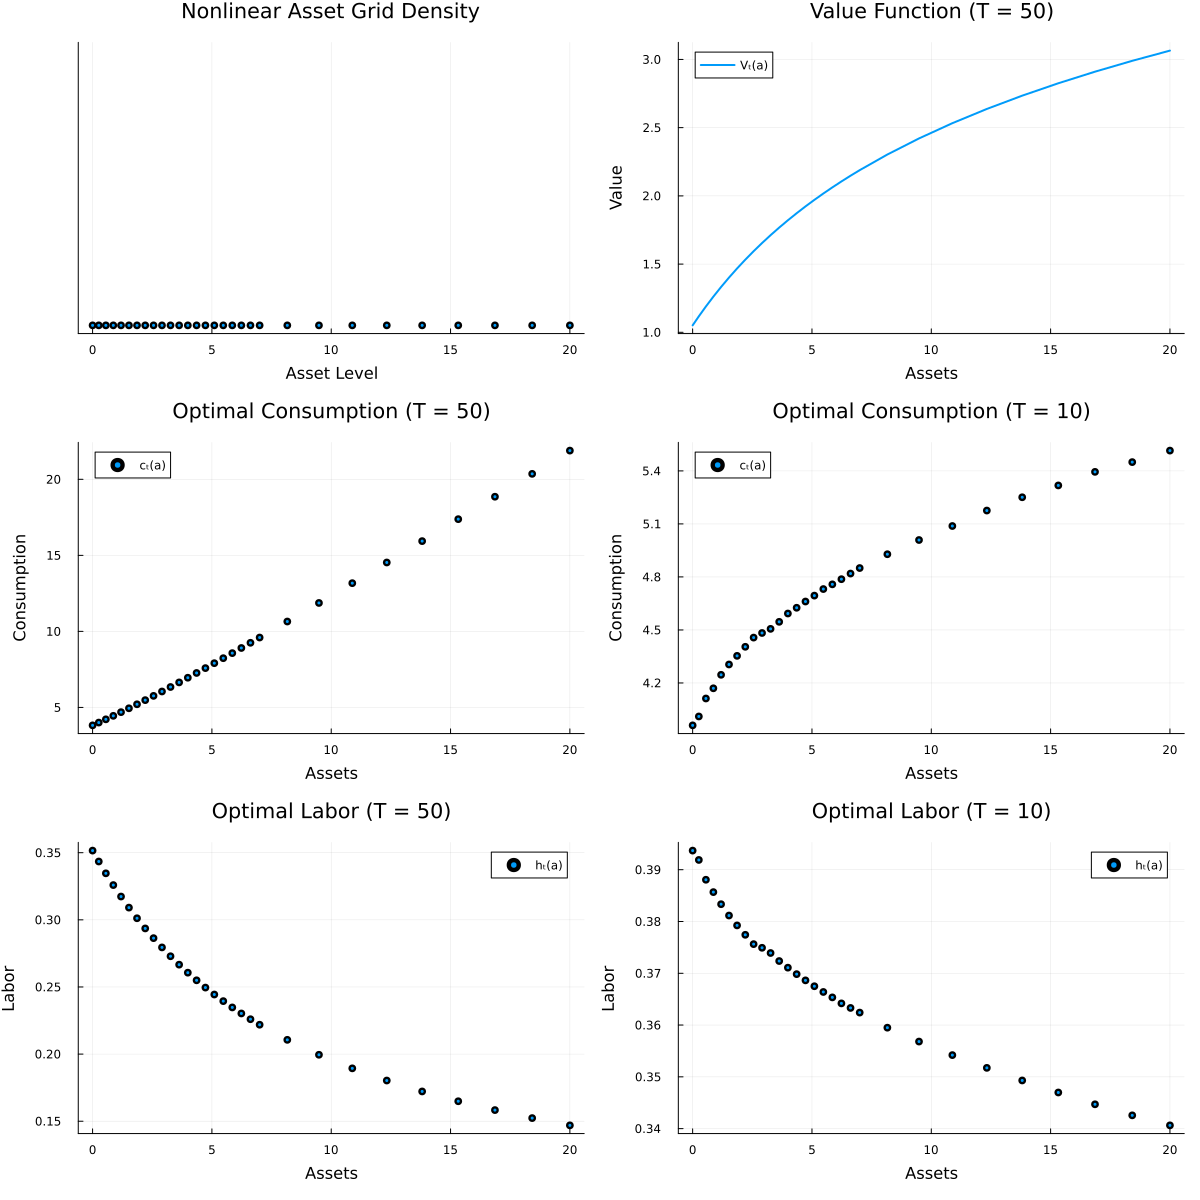

In [36]:

# Choose a representative labor grid index (e.g. the median)
k_mid = Int(ceil(length(model_baseline.k_grid)/2))
t_mid = Int(ceil(length(model_baseline.t_grid)/2))
p_mid = Int(ceil(length(model_baseline.p_grid)/2))
T_terminal = model_baseline.T  # Terminal period (e.g., 50)
t_early = 10          # An earlier period for comparison

# 1. Plot the nonlinear asset grid
p1 = scatter(model_baseline.a_grid, zeros(length(model_baseline.a_grid)),
    xlabel = "Asset Level",
    yticks = [],
    title = "Nonlinear Asset Grid Density",
    markersize = 3,
    legend = false)

# 2. Plot optimal consumption policy at terminal period (T = model.T)
# Here we fix the labor dimension at k_mid.
p2 = scatter(model_baseline.a_grid, model_baseline.sol_c[T_terminal, :, k_mid, t_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Consumption",
    title = "Optimal Consumption (T = $(T_terminal))",
    label = "cₜ(a)",
    markersize = 3)

# 3. Plot value function at terminal period (T = model.T)
# Note: use 'sol_v' (not sol_V) as per your definition.
p3 = plot(model_baseline.a_grid, model_baseline.sol_v[T_terminal, :, k_mid, t_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Value",
    title = "Value Function (T = $(T_terminal))",
    label = "Vₜ(a)",
    linewidth = 2)

# 4. Plot optimal consumption policy at an earlier period (e.g., T = 10)
p4 = scatter(model_baseline.a_grid, model_baseline.sol_c[t_early, :, k_mid, t_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Consumption",
    title = "Optimal Consumption (T = $(t_early))",
    label = "cₜ(a)",
    markersize = 3)

p5 = scatter(model_baseline.a_grid, model_baseline.sol_h[t_early, :, k_mid, t_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Labor",
    title = "Optimal Labor (T = $(t_early))",
    label = "hₜ(a)",
    markersize = 3)

p6 = scatter(model_baseline.a_grid, model_baseline.sol_h[T_terminal, :, k_mid, t_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Labor",
    title = "Optimal Labor (T = $(T_terminal))",
    label = "hₜ(a)",
    markersize = 3)

# Combine all plots into a 2×2 grid layout for comparison
plot(p1, p3, p2, p4, p6, p5, layout = (3, 2), size = (1200, 1200), margin=2mm)

In [37]:
t = 1:model_baseline.simT

function extract_all(model)
    return (
        c = mean(model.sim_c, dims=1)[:] .* 10,
        a = mean(model.sim_a, dims=1)[:] .* 10,
        h = mean(model.sim_h, dims=1)[:],
        k = mean(model.sim_k, dims=1)[:],
        income = mean(model.sim_income, dims=1)[:] .* 10,
        wage = mean(model.sim_w_eff, dims=1)[:]
    )
end



extract_all (generic function with 1 method)

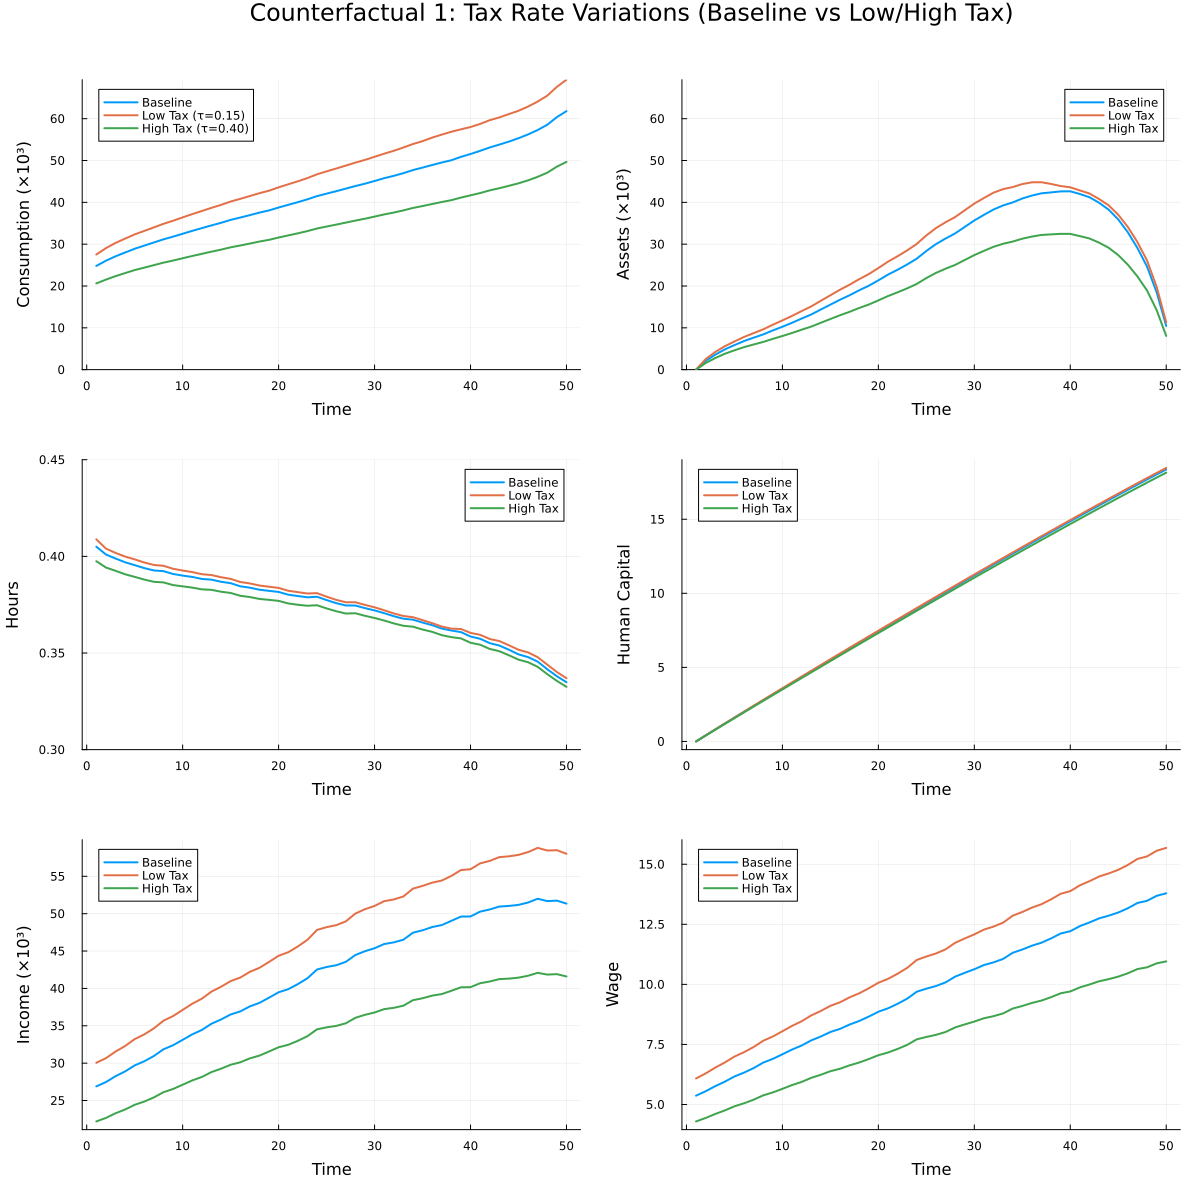

In [42]:
# ----------------------------------------------
# 1. Tax Rate Variations (Low and High Tax)
# ----------------------------------------------

thousand_formatter = (val -> @sprintf("%.0f", val/1_000))

# Extract data for each scenario
base = extract_all(model_baseline)
low_tax = extract_all(model_low_tax)
high_tax = extract_all(model_high_tax)

# Time vector (assuming t is defined, e.g., t = 1:model_baseline.T)
t = 1:length(base.c)  # Adjust based on your model's time horizon
ymax_c = maximum(vcat(base.c, low_tax.c, high_tax.c))
# Plot 1: Consumption
p1 = plot(t, base.c, label="Baseline", lw=2, xlabel="Time", ylabel="Consumption (×10³)",
            ylims=(0, ymax_c))
plot!(p1, t, low_tax.c, label="Low Tax (τ=0.15)", lw=2)
plot!(p1, t, high_tax.c, label="High Tax (τ=0.40)", lw=2)


# Plot 2: Assets
ymax_a = maximum(vcat(base.a, low_tax.a, high_tax.a, ymax_c))
p2 = plot(t, base.a, label="Baseline", lw=2, xlabel="Time", ylabel="Assets (×10³)",
            ylims=(0, ymax_a))
plot!(p2, t, low_tax.a, label="Low Tax", lw=2)
plot!(p2, t, high_tax.a, label="High Tax", lw=2)


# Plot 3: Hours
p3 = plot(t, base.h, label="Baseline", lw=2, xlabel="Time", ylabel="Hours", ylims=(0.3, 0.45))
plot!(p3, t, low_tax.h, label="Low Tax", lw=2)
plot!(p3, t, high_tax.h, label="High Tax", lw=2)

# Plot 4: Human Capital
p4 = plot(t, base.k, label="Baseline", lw=2, xlabel="Time", ylabel="Human Capital")
plot!(p4, t, low_tax.k, label="Low Tax", lw=2)
plot!(p4, t, high_tax.k, label="High Tax", lw=2)

# Plot 5: Income
p5 = plot(t, base.income, label="Baseline", lw=2, xlabel="Time", ylabel="Income (×10³)")
plot!(p5, t, low_tax.income, label="Low Tax", lw=2)
plot!(p5, t, high_tax.income, label="High Tax", lw=2)


# Plot 6: Wage
p6 = plot(t, base.wage, label="Baseline", lw=2, xlabel="Time", ylabel="Wage")
plot!(p6, t, low_tax.wage, label="Low Tax", lw=2)
plot!(p6, t, high_tax.wage, label="High Tax", lw=2)


# Combine into a 3x2 layout
combined_plot = plot(p1, p2, p3, p4, p5, p6,
                     layout=(3, 2),
                     size=(1200, 1200),
                     plot_title="Counterfactual 1: Tax Rate Variations (Baseline vs Low/High Tax)",
                     titlefont=16,
                     margin=3mm)